In [3]:
# Implying LASSO (Sparse regression)
# min. of c ||Ac - d||^2 + \lambda||c||_1

In [8]:
import numpy as np
A = np.loadtxt("shadows_matrix.txt")
A = A.T
d = np.loadtxt("dph1.txt")
noise = np.random.rand(256)
d_noisy = d + 0.1*noise
#print(d_noisy)

In [42]:
import sklearn as skl
from sklearn import linear_model
from sklearn.linear_model import Lasso

alpha_val = 1e-2

model = Lasso(alpha=alpha_val, positive=True, max_iter=200000, tol=1e-8)
model.fit(A,d_noisy)
c_lasso = model.coef_

In [43]:
idx = np.argsort(c_lasso)[::-1]
for i in idx[:10]:
    print(i, c_lasso[i])

50 29.743811498595992
512 14.940204785240999
328 0.0
327 0.0
326 0.0
325 0.0
324 0.0
323 0.0
322 0.0
321 0.0


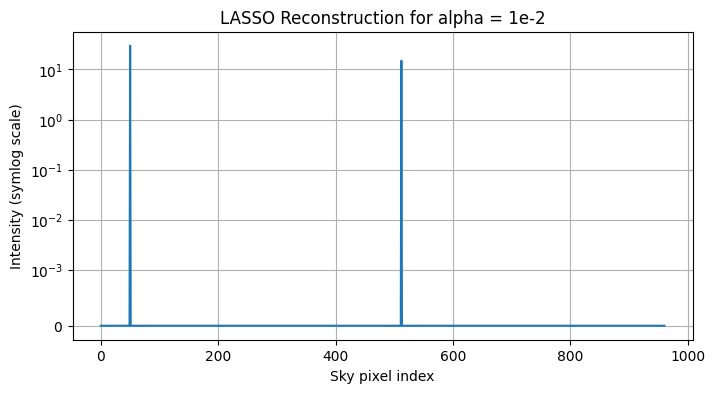

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(c_lasso)
plt.yscale("symlog", linthresh=1e-3)
plt.xlabel("Sky pixel index")
plt.ylabel("Intensity (symlog scale)")
plt.title("LASSO Reconstruction for alpha = 1e-2")
plt.grid(True)
plt.show()